The Bike Sharing Demand Prediction project focuses on predicting the demand for bike-sharing services based on various factors like weather conditions, time of day, and other relevant data. By using machine learning models, it aims to forecast the number of bikes required at different locations and times, helping optimize bike distribution and improve service efficiency.

Saving archive (1).zip to archive (1).zip
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1

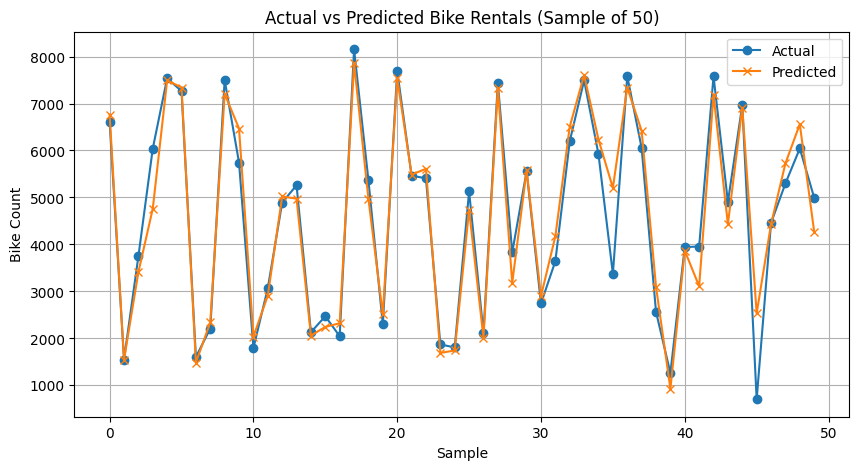

In [1]:
# Upload and extract the dataset
from google.colab import files
import zipfile
import os

uploaded = files.upload()  # Upload the ZIP file you downloaded from Kaggle

zip_path = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/bike_data")

data_dir = "/content/bike_data"

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset (day.csv)
df = pd.read_csv(os.path.join(data_dir, "day.csv"))

# Display the first few rows
print(df.head())

# Drop unnecessary columns
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

# Define features and target
X = df.drop('cnt', axis=1)
y = df['cnt']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error: {mse}")
print(f"R² Score: {r2}")

# Plot predictions vs actual
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title("Actual vs Predicted Bike Rentals (Sample of 50)")
plt.xlabel("Sample")
plt.ylabel("Bike Count")
plt.legend()
plt.grid(True)
plt.show()
